<div style="display: flex; gap: 10px;">
  <img src="../images/HOOPS_AI.jpg" style="width: 20%;">

# Predicting multiple categories with the HOOPS AI Context Layer

This tutorial combines **CAD similarity search** with the **Context Layer** to assign
**several categories at once** to a query part — a *multi-label* problem.

A part rarely belongs to a single group. In a furniture catalog one product can be
**Accessories**, **Casegoods** *and* **Storage** at the same time; in mechanical design a
flanged bushing is **Rotational**, **Sealing** *and* **Mounting** all at once. A classifier
that outputs only one label cannot describe these parts.

**The idea in one line:** shape retrieval finds the parts that look like the query, each
neighbour already carries a *set* of category tags, and the Context Layer aggregates those
tags into the **set of categories** that best fits the query — no model retraining required.

**Single-label vs. multi-label.** The built-in `CategoricalRule` answers *"which one
category wins?"* (softmax over neighbours, then argmax). Here we plug in a small custom
`MultiLabelRule` that answers *"which categories apply?"* — it scores every category
**independently** (a sigmoid-like vote) and keeps each one above a threshold. This is the
same change you would otherwise make to a trained model's **loss** (cross-entropy → binary
cross-entropy) and **activation** (softmax → sigmoid), expressed at the aggregation layer so
you can try it immediately.

**Prerequisites — indexed database:** This notebook loads a pre-built FAISS index produced
by [`demo_HOOPS_Embeddings_indexing.ipynb`](./demo_HOOPS_Embeddings_indexing.ipynb). Run
that notebook first if you haven't already.

**API reference:** [hoops_ai.ml.context_layer](https://docs.techsoft3d.com/hoops/ai/api_ref/hoops_ai.ml.context_layer.html)

## Dataset

This notebook uses the **TMCAD** dataset (Truly Mechanical CAD Dataset):

> Zou, Q., & Zhu, L. (2025). Bringing attention to CAD: Boundary representation learning via transformer. *Computer-Aided Design*, 103940.

- TMCAD v2 (recommended): <https://pan.zju.edu.cn/share/218d10a88e8c18f5b96e94a7e0>
- Documentation: <https://github.com/Qiang-Zou/BRT/blob/main/DATASET.md>

~10,000 STEP models across 10 mechanical part categories. Released under **GPL-3.0**.


## Workflow at a glance

![Retrieval + Context Layer workflow](../images/workflow_retrieval_context.png)


In [1]:
import hoops_ai
import os
import sys

license_key = os.environ.get("HOOPS_AI_LICENSE")
if not license_key:
    sys.exit("HOOPS_AI_LICENSE environment variable is required.")

hoops_ai.set_license(license_key, validate=True)

------------------------------------------------------------
HOOPS AI
------------------------------------------------------------
  Platform      : Windows 11
  Architecture  : AMD64
  Python        : 3.12.10
------------------------------------------------------------
  Core          : hoops-ai             1.2.0.dev
  CAD Access    : hoops-exchange       26.2.0  (build: 1e11169 2026-06-12T10:38:16Z)
  Conversion    : hoops-converter      26.1.1  (build: 00dc9f6 2026-06-12T10:22:46Z)
  Insights      : hoops-web-viewer     26.1.1  (build: d30058f 2026-06-12T10:22:25Z)
------------------------------------------------------------
[OK] HOOPS AI License: Valid


# Configure

In [2]:
from hoops_ai.ml.embeddings import HOOPSEmbeddings, Embedding, EmbeddingBatch
import pathlib

packages_dir = pathlib.Path.cwd().parent.joinpath("packages")
pretrained_model = packages_dir.joinpath("trained_ml_models", "ts3d_2M_hoops_embeddings_SIGNAL-preview.ckpt")
demo_cad_files_folder = packages_dir.joinpath("vectorstores","tmcad","queries_for_demo")
indexed_database = packages_dir.joinpath("vectorstores","tmcad","TMCAD_SIGNAL.faiss")

# Register your custom model (trained using EmbeddingFlowModel)
HOOPSEmbeddings.register_model(
    model_name="HOOPS Embeddings SIGNAL preview",
    checkpoint_path=str(pretrained_model)
)

print(HOOPSEmbeddings.list_available_models())

['HOOPS Embeddings SIGNAL preview']


## 1. Set up the CAD similarity search

Register the pre-trained model, load the FAISS index built in
[`demo_HOOPS_Embeddings_indexing.ipynb`](./demo_HOOPS_Embeddings_indexing.ipynb),
and point to a folder of query CAD files. These are the same retrieval building blocks
used throughout the embeddings tutorials.

In [3]:

embedder = HOOPSEmbeddings(model="HOOPS Embeddings SIGNAL preview")

print(f"Using model: {embedder.model_name} with dimension: {embedder.embedding_dim}")

Successfully loaded model from checkpoint: c:\Users\LuisSalazar.LY-LS-LEGION\Documents\repos\HOOPS-AI-tutorials\packages\trained_ml_models\ts3d_2M_hoops_embeddings_SIGNAL-preview.ckpt
Using model: HOOPS Embeddings SIGNAL preview with dimension: 2048


In [4]:
from hoops_ai.storage import CADFileRetriever, LocalStorageProvider

retriever = CADFileRetriever(storage_provider=LocalStorageProvider(directory_path=demo_cad_files_folder), formats=[".stp", ".step", ".iges", ".igs"])
            
# Get files using the library's retriever
cad_files = retriever.get_file_list()
print(len(cad_files), "files found." )


20 files found.


In [5]:
from hoops_ai.ml import CADSearch

loaded_searcher = CADSearch(shape_model=embedder)

embeddingBatch = loaded_searcher.load_shape_index(path=str(indexed_database))

print(f"Loaded {len(embeddingBatch.ids)} part embeddings (dim={embeddingBatch.values.shape[1]}).")


Loaded 39736 part embeddings (dim=2048).


In [6]:
from hoops_ai.insights import DatasetViewer

ds_viewer = DatasetViewer([], [], [], reference_dir=packages_dir.joinpath("vectorstores","tmcad","images_tmcad"))

## 2. From one label to many

Once retrieval tells us which parts look like the query, the **Context Layer** aggregates
the metadata of those neighbours. Three objects from
[`hoops_ai.ml.context_layer`](https://docs.techsoft3d.com/hoops/ai/api_ref/hoops_ai.ml.context_layer.html)
are involved:

| Object | Role |
|---|---|
| `ContextProvider` | Supplies metadata for a list of part ids. Here it returns each part's **list of categories**. It lives in `multilabel_database.py`. |
| `AggregationRule` | Defines how neighbour values are combined. The built-in `CategoricalRule` picks a single winner; for multi-label we define a small **`MultiLabelRule`** **directly in this notebook** (next section) so you can read and adapt the logic. |
| `ContextPredictor` | Orchestrates the prediction. `predictor.infer(hits, keys=[...])` runs the rule for each key and returns a `dict[str, ContextPrediction]` with `value`, `confidence`, and `status`. |

The only change needed for multi-label is the rule. `CategoricalRule` returns the single
**argmax** category; `MultiLabelRule` scores every category **independently** and keeps
each one above a threshold. The next section shows exactly how — in ~25 lines you can edit.

### 2.1 — Inside `MultiLabelRule` (the part you can change)

`MultiLabelRule` turns neighbour evidence into a set of categories in three numerical
steps. For one query the predictor hands the rule:
- `values` — each neighbour's list of categories $L_i$.
- `scores` — the matching cosine similarities $s_i \in [0, 1]$.

**Step 1 — weight the neighbours (softmax over scores).** Closer neighbours count more, so
we soften the scores into weights with a temperature $\tau$:

$$w_i = \frac{e^{\tau s_i}}{\sum_j e^{\tau s_j}}, \qquad \sum_i w_i = 1$$

Larger $\tau$ concentrates the vote on the closest matches; $\tau = 0$ makes every neighbour
count equally. Same softmax you know — but over *neighbours*, not labels.

**Step 2 — one independent probability per label (the sigmoid analogue).** For each
category $\ell$ we sum the weight of the neighbours that carry it:

$$p(\ell) = \sum_{i \,:\, \ell \in L_i} w_i \;\in [0, 1]$$

These probabilities are **independent** — they do *not* sum to 1 across labels, so a part
can score high on several categories at once.

**Step 3 — threshold (the decision).** Keep every category whose probability clears $\theta$:

$$\hat{y} = \{\, \ell : p(\ell) \ge \theta \,\}$$

`CategoricalRule` instead runs softmax *across the labels* then `argmax` — a single winner.
The two rules share Step 1 and differ only in Steps 2–3.

**Knobs you may want to change:** the weighting kernel in Step 1 (raw scores, a Gaussian
distance kernel, or a hard top-$k$ cutoff), the threshold $\theta$ in Step 3 (per category,
or calibrated on a validation set), class priors before thresholding, or the confidence
summary. The implementation below is intentionally short so you can edit any of these in place.


In [ ]:
import numpy as np
from hoops_ai.ml.context_layer import AggregationRule, ContextPrediction


def score_labels(label_lists, scores, *, temperature: float = 8.0) -> dict[str, float]:
    """Steps 1 + 2: an independent probability per label (the multi-label 'sigmoid').

    Returns ``{label: probability}`` with each probability in [0, 1]. The probabilities are
    computed per label and do NOT sum to 1 across labels — that is what makes this
    multi-label rather than single-winner.
    """
    if not label_lists:
        return {}
    scores = np.asarray(scores, dtype=np.float64)
    # Step 1 — softmax over neighbour similarity scores (temperature = how sharply the
    # closest neighbours dominate the vote).
    weights = np.exp(temperature * (scores - scores.max()))
    weights /= weights.sum()
    # Step 2 — accumulate each label's weight across the neighbours that carry it.
    probabilities: dict[str, float] = {}
    for labels, weight in zip(label_lists, weights):
        labels = [labels] if isinstance(labels, str) else list(labels)
        for label in labels:
            probabilities[label] = probabilities.get(label, 0.0) + float(weight)
    return probabilities


class MultiLabelRule(AggregationRule):
    """Predict a SET of categories by independent per-label thresholding.

    Subclasses the library's ``AggregationRule``, so ``ContextPredictor`` treats it like
    any other rule. To change the behaviour, edit the math in :func:`score_labels` (the
    weighting / scoring) or the threshold logic in :meth:`predict` (the decision).
    """

    def __init__(self, threshold: float = 0.35, temperature: float = 8.0) -> None:
        self.threshold = threshold
        self.temperature = temperature

    def predict(self, values, scores, key):
        probabilities = score_labels(values, scores, temperature=self.temperature)
        if not probabilities:
            return None
        ranked = sorted(probabilities.items(), key=lambda item: item[1], reverse=True)
        # Step 3 — keep every label above the threshold (the decision / activation).
        selected = [label for label, prob in ranked if prob >= self.threshold]
        rejected = [(label, prob) for label, prob in ranked if prob < self.threshold]
        if not selected:
            return None
        confidence = float(np.mean([probabilities[label] for label in selected]))
        return ContextPrediction(
            value=selected,
            confidence=confidence,
            evidence_count=len(values),
            alternatives=[{"value": label, "confidence": prob} for label, prob in rejected[:4]],
        )

## 3. The example catalog (mock — not part of the library)

`multilabel_database.py` provides `MultiLabelContextProvider`: a `ContextProvider` subclass
that synthesises deterministic, multi-label records from each file's stem so the notebook
runs without a real catalog. Each record is a `{"Categories": [...]}` list drawn from six
overlapping mechanical groups: `Rotational`, `Fastening`, `Structural`, `Housing`,
`Sealing`, `Mounting`.

To mimic a real, partially-tagged catalog it deliberately leaves gaps:

- **The top hit is always empty** — the query's nearest geometric twin is not tagged yet, so
  the predictor must aggregate categories from the rest of the neighbourhood.
- About **20 %** of the other parts are untagged; the rest carry one to three categories.
- About **70 %** of queries fall into a "shape family" that shares 2-3 categories (with light
  per-part noise), so the predictor can recover a confident multi-label set. The rest stay
  divided, giving sparser, lower-confidence predictions.

> In your own project, replace `MultiLabelContextProvider` with a `ContextProvider` subclass
> backed by your real catalog or PLM — only `get_contexts` needs to return the list of
> categories per part.


In [ ]:
import importlib, multilabel_database
importlib.reload(multilabel_database)
from multilabel_database import MultiLabelContextProvider, TAGS, CATEGORY_KEY

from hoops_ai.ml.context_layer import ContextPredictor
from hoops_ai.insights import predictions_table, hits_table

# search_by_shape returns a list-of-lists (one neighbour list per query);
# we always work on the first query.
part_index = 0

# --- Example-only mock. Swap for your own ContextProvider in production. ---
context_provider = MultiLabelContextProvider()

# --- MultiLabelRule + score_labels are defined above, in this notebook, so the
#     softmax/threshold logic is fully editable here. ---
multilabel_rule = MultiLabelRule(threshold=0.35, temperature=8.0)

# --- The predictor: route the "Categories" key to the multi-label rule. ---
predictor = ContextPredictor(
    context_provider,
    per_key_rules={CATEGORY_KEY: multilabel_rule},
)

print("Category vocabulary:", list(TAGS))

Category vocabulary: ['Rotational', 'Fastening', 'Structural', 'Housing', 'Sealing', 'Mounting']


## 4. Predict the categories

For each query we:

1. Run a shape search with `loaded_searcher.search_by_shape(query, top_k=...)`.
2. Inspect the neighbours and their category tags with `hits_table`.
3. Call `predictor.infer(hits, keys=["Categories"])` and render the result with
   `predictions_table`.

Because the key is handled by `MultiLabelRule`, each `ContextPrediction.value` is now a
**list of categories** rather than a single value.

### Example 1 — a clear shape family

The neighbours mostly share the same 2-3 categories. We expect `MultiLabelRule` to recover
that whole set, each category sitting comfortably above the threshold.

Querying with: c:\Users\LuisSalazar.LY-LS-LEGION\Documents\repos\HOOPS-AI-tutorials\packages\vectorstores\tmcad\queries_for_demo\1.stp
Reusing 15 existing PNGs and generating 0 new PNGs...


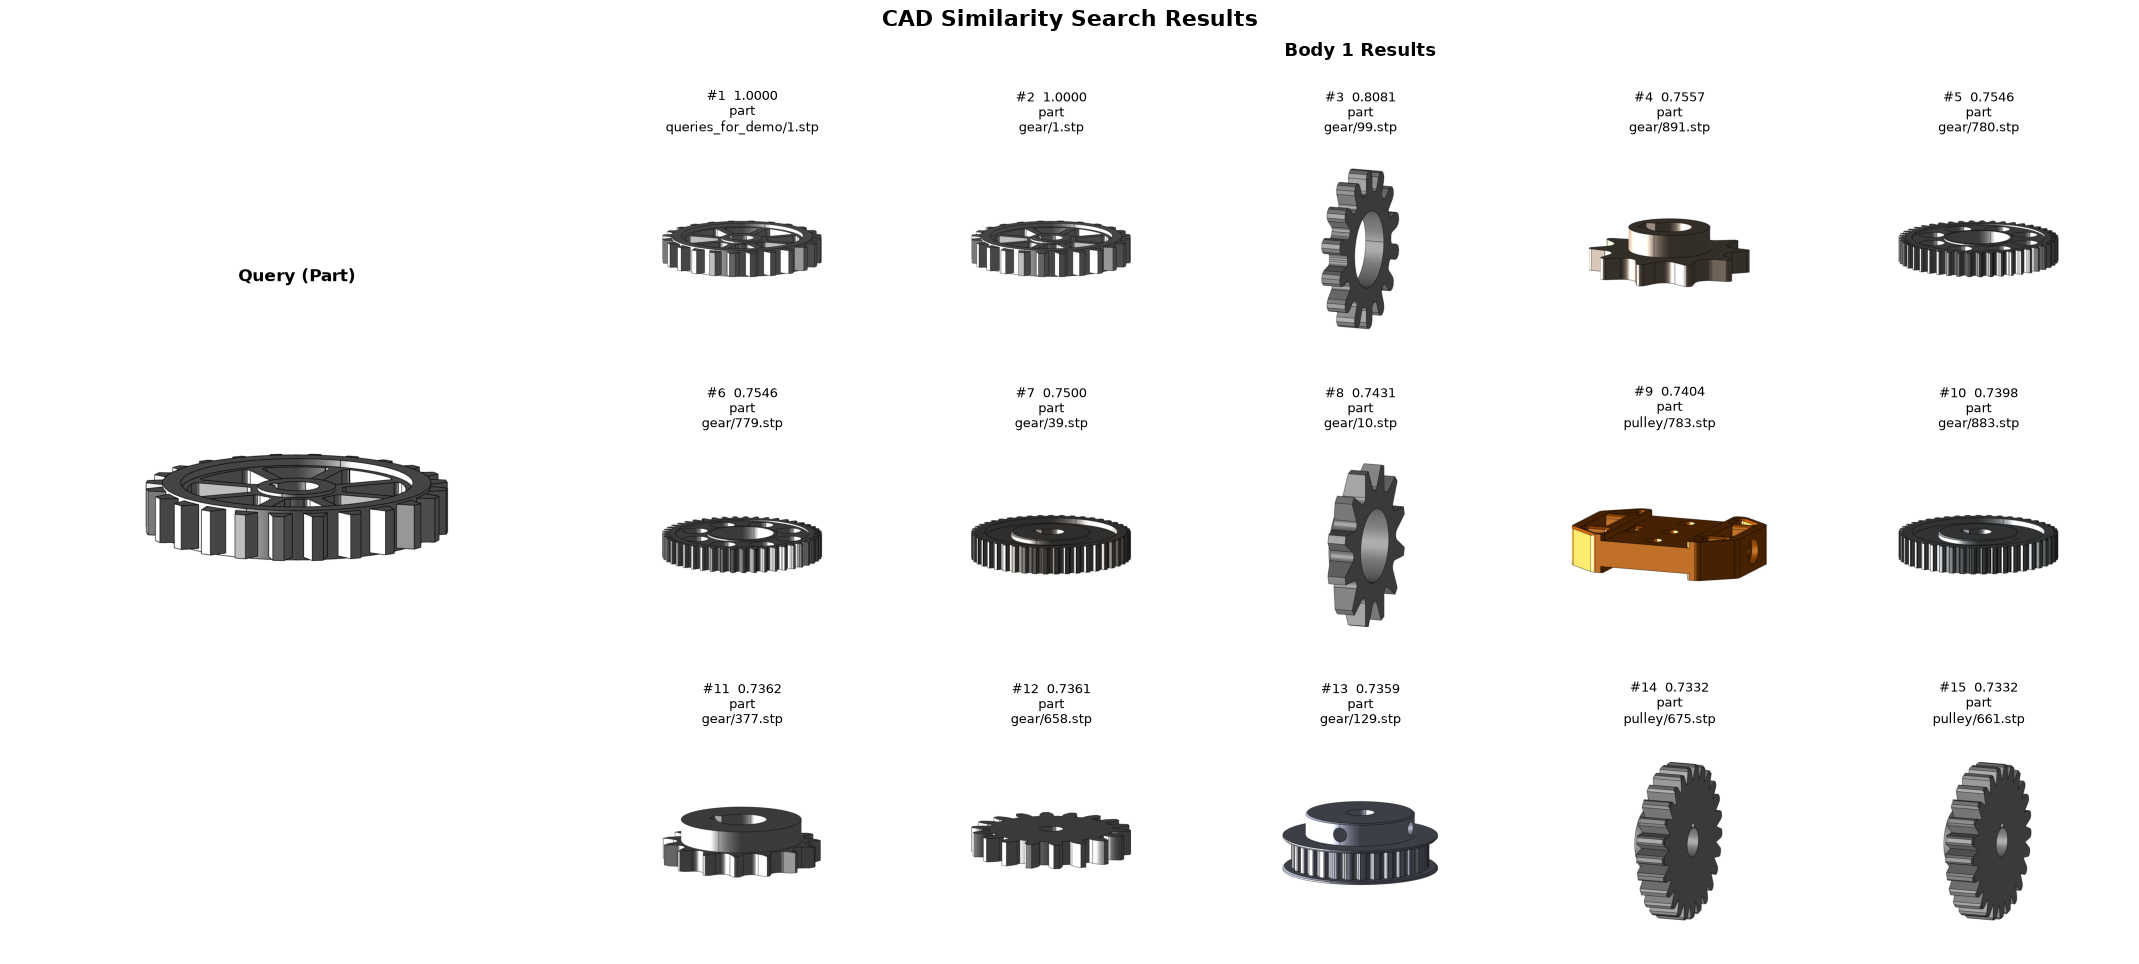

In [8]:
query = str(cad_files[1])
print(f"Querying with: {query}")
hits = loaded_searcher.search_by_shape(query, top_k=15, filters={"kind": "part"})

ds_viewer.show_search_results(hits, query_file=query, grid_cols=5)

In [9]:
# The categories attached to each neighbour. Note that many parts carry several at once,
# and the top hit (the query's nearest twin) has no tags yet.
metadata_by_id = context_provider.get_contexts([h.id for h in hits[part_index]])
hits_table(hits[part_index], metadata_by_id, keys=[CATEGORY_KEY])

,id,score,Categories
rank,,,
1,C:\Users\LuisSalazar.LY-LS-LEGION\Documents\data\TMCAD_dataset_v2\queries_for_demo\1.stp,1.00,—
2,C:\Users\LuisSalazar.LY-LS-LEGION\Documents\data\TMCAD_dataset_v2\gear\1.stp,1.00,—
3,C:\Users\LuisSalazar.LY-LS-LEGION\Documents\data\TMCAD_dataset_v2\gear\99.stp,0.81,"['Housing', 'Sealing']"
4,C:\Users\LuisSalazar.LY-LS-LEGION\Documents\data\TMCAD_dataset_v2\gear\891.stp,0.76,['Rotational']
5,C:\Users\LuisSalazar.LY-LS-LEGION\Documents\data\TMCAD_dataset_v2\gear\780.stp,0.75,"['Rotational', 'Sealing']"
6,C:\Users\LuisSalazar.LY-LS-LEGION\Documents\data\TMCAD_dataset_v2\gear\779.stp,0.75,['Structural']
7,C:\Users\LuisSalazar.LY-LS-LEGION\Documents\data\TMCAD_dataset_v2\gear\39.stp,0.75,['Sealing']
8,C:\Users\LuisSalazar.LY-LS-LEGION\Documents\data\TMCAD_dataset_v2\gear\10.stp,0.74,"['Housing', 'Rotational']"
9,C:\Users\LuisSalazar.LY-LS-LEGION\Documents\data\TMCAD_dataset_v2\pulley\783.stp,0.74,['Sealing']


In [10]:
# The prediction value is a LIST of categories — every label that cleared the threshold.
predictions = predictor.infer(hits[part_index], keys=[CATEGORY_KEY])
predictions_table(predictions)

,value,confidence,status,coverage
key,,,,
Categories,['Sealing'],65%,ready_to_propose,11/15


In [11]:
# Look under the hood: the independent probability the rule gives each category
# (the "sigmoid" outputs). Every bar at or above the threshold becomes a predicted label.
import pandas as pd

neighbour_tags = [metadata_by_id.get(h.id, {}).get(CATEGORY_KEY, []) for h in hits[part_index]]
neighbour_scores = [h.score for h in hits[part_index]]
probabilities = score_labels(neighbour_tags, neighbour_scores)

probs = pd.Series(probabilities).reindex(list(TAGS)).fillna(0.0).sort_values(ascending=False)
(probs.to_frame("probability").style
    .format({"probability": "{:.0%}"})
    .bar(subset=["probability"], color="#90caf9", vmin=0, vmax=1)
    .set_caption(f"Per-category probability (threshold = {multilabel_rule.threshold:.0%})"))

,probability
Sealing,26%
Housing,12%
Rotational,11%
Structural,4%
Fastening,3%
Mounting,0%


### Tuning the decision threshold

The threshold is the multi-label equivalent of deciding how confident the model must be
before it commits to a label. Lower it to admit more categories (**higher recall**); raise
it to keep only the strongest (**higher precision**). Same neighbours, three thresholds.

In [12]:
# Reuse Example 1's neighbours and vary only the threshold.
for t in (0.25, 0.5, 0.7):
    tuned = ContextPredictor(
        context_provider, per_key_rules={CATEGORY_KEY: MultiLabelRule(threshold=t)},
    )
    pred = tuned.infer(hits[part_index], keys=[CATEGORY_KEY])[CATEGORY_KEY]
    print(f"threshold={t:.0%} -> {pred.value}")

threshold=25% -> ['Sealing', 'Housing', 'Rotational']
threshold=50% -> ['Sealing']
threshold=70% -> None


### Example 2 — sparse and divided neighbours

This query sits outside any clear shape family: several neighbours are untagged and the
rest disagree. `MultiLabelRule` keeps only the categories that still clear the threshold
and reports a lower confidence — exactly what you want when the evidence is thin, instead
of over-committing to a full label set.

Querying with: c:\Users\LuisSalazar.LY-LS-LEGION\Documents\repos\HOOPS-AI-tutorials\packages\vectorstores\tmcad\queries_for_demo\133.stp
Reusing 15 existing PNGs and generating 0 new PNGs...


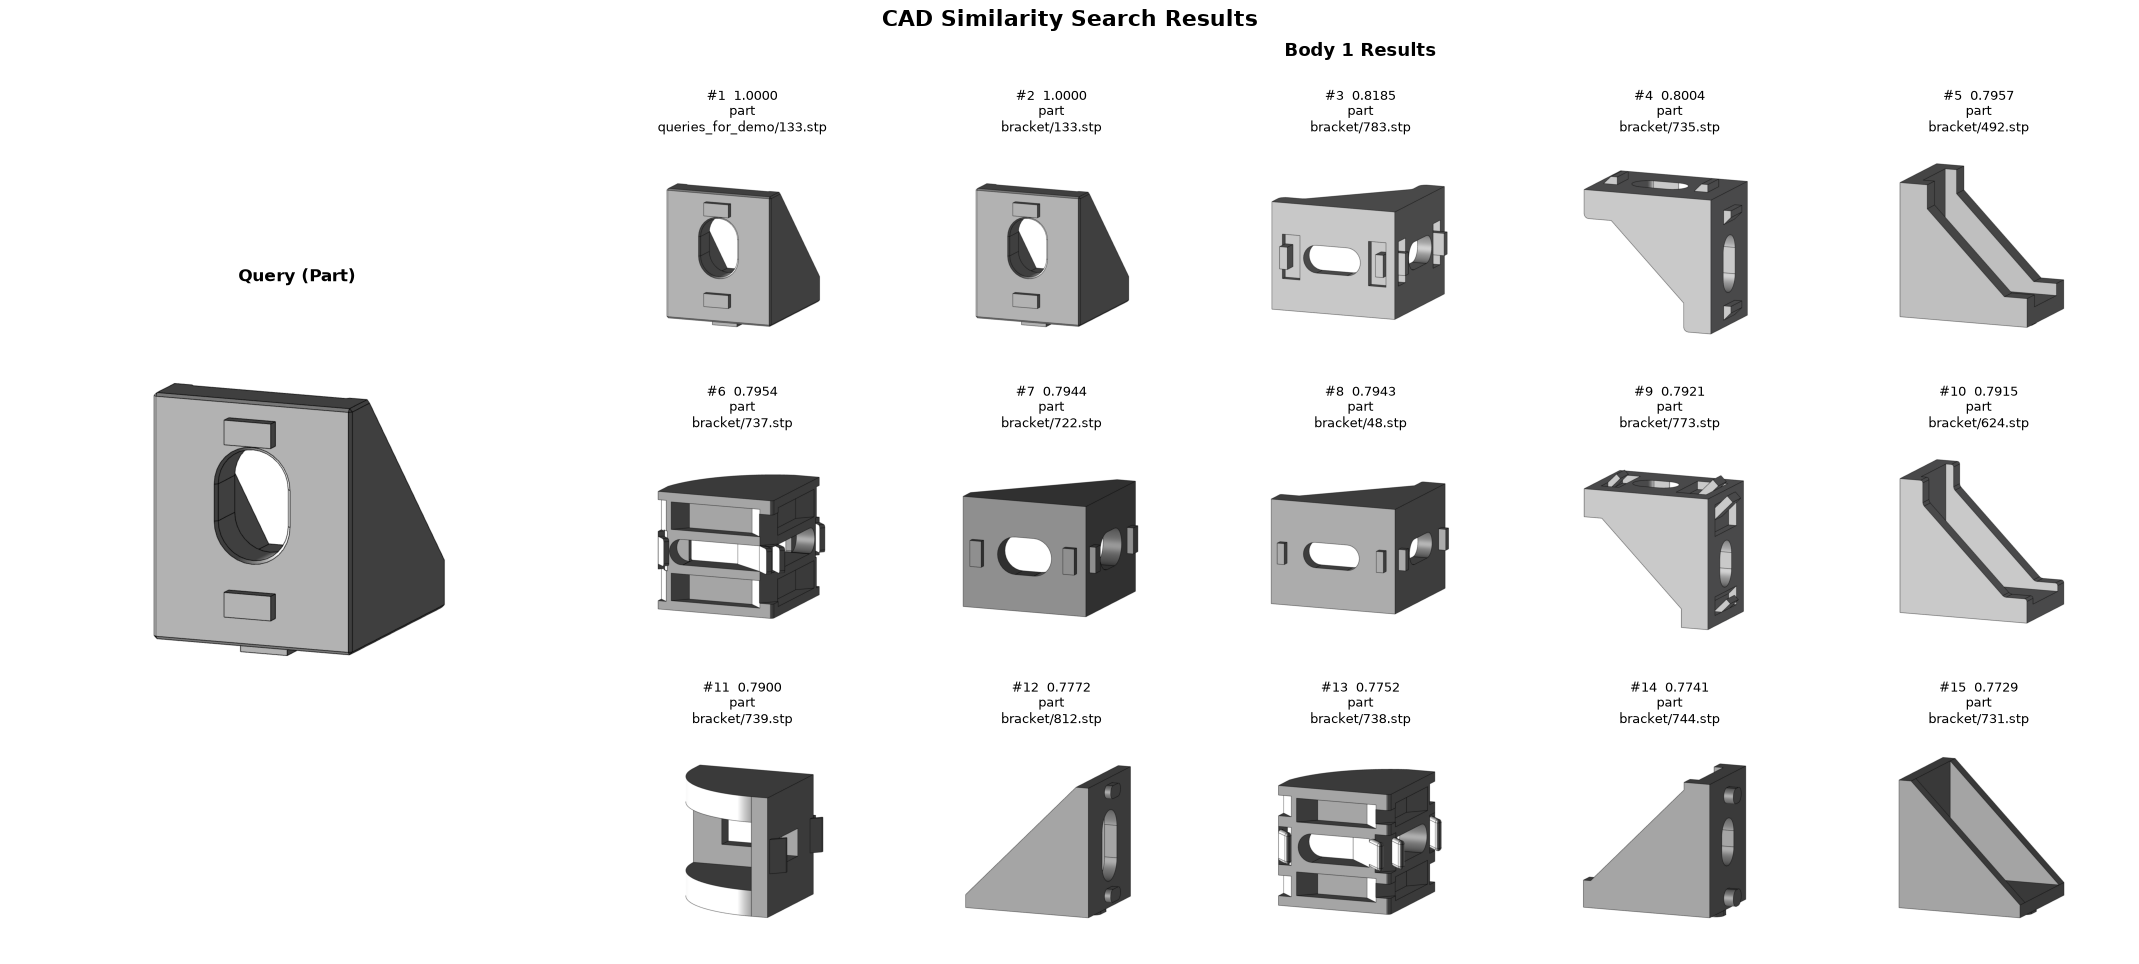

In [13]:
query = str(cad_files[4])
print(f"Querying with: {query}")
hits = loaded_searcher.search_by_shape(query, top_k=15, filters={"kind": "part"})

ds_viewer.show_search_results(hits, query_file=query, grid_cols=5)

In [14]:
metadata_by_id = context_provider.get_contexts([h.id for h in hits[part_index]])
hits_table(hits[part_index], metadata_by_id, keys=[CATEGORY_KEY])

,id,score,Categories
rank,,,
1,C:\Users\LuisSalazar.LY-LS-LEGION\Documents\data\TMCAD_dataset_v2\queries_for_demo\133.stp,1.00,—
2,C:\Users\LuisSalazar.LY-LS-LEGION\Documents\data\TMCAD_dataset_v2\bracket\133.stp,1.00,"['Fastening', 'Housing', 'Structural']"
3,C:\Users\LuisSalazar.LY-LS-LEGION\Documents\data\TMCAD_dataset_v2\bracket\783.stp,0.82,"['Fastening', 'Housing', 'Rotational', 'Sealing']"
4,C:\Users\LuisSalazar.LY-LS-LEGION\Documents\data\TMCAD_dataset_v2\bracket\735.stp,0.80,"['Fastening', 'Housing', 'Rotational']"
5,C:\Users\LuisSalazar.LY-LS-LEGION\Documents\data\TMCAD_dataset_v2\bracket\492.stp,0.80,"['Fastening', 'Housing', 'Rotational']"
6,C:\Users\LuisSalazar.LY-LS-LEGION\Documents\data\TMCAD_dataset_v2\bracket\737.stp,0.80,"['Housing', 'Rotational']"
7,C:\Users\LuisSalazar.LY-LS-LEGION\Documents\data\TMCAD_dataset_v2\bracket\722.stp,0.79,"['Fastening', 'Housing', 'Rotational']"
8,C:\Users\LuisSalazar.LY-LS-LEGION\Documents\data\TMCAD_dataset_v2\bracket\48.stp,0.79,"['Fastening', 'Housing', 'Rotational']"
9,C:\Users\LuisSalazar.LY-LS-LEGION\Documents\data\TMCAD_dataset_v2\bracket\773.stp,0.79,"['Fastening', 'Housing', 'Rotational', 'Sealing']"


In [15]:
predictions = predictor.infer(hits[part_index], keys=[CATEGORY_KEY])
predictions_table(predictions)

,value,confidence,status,coverage
key,,,,
Categories,"['Housing', 'Fastening', 'Rotational']",87%,ready_to_propose,12/15


## Where to go from here

- **Plug in your own catalog.** Replace `MultiLabelContextProvider` with a
  `ContextProvider` subclass backed by your PLM, ERP, or any metadata store; just return
  the list of categories per part from `get_contexts`.
- **Tune the rule.** Adjust `threshold` (precision vs. recall) and `temperature` (how much
  the closest neighbours dominate the vote) on `MultiLabelRule`.
- **Write your own rule.** `MultiLabelRule` is a short `AggregationRule` subclass defined
  in this notebook — copy it as a starting point for any custom voting logic.
- **Bake multi-label into a trained model.** The retrieval approach above needs no
  training. To predict multiple labels directly from a trained classifier, swap its
  **loss** (cross-entropy → binary cross-entropy) and **activation** (softmax → sigmoid)
  while keeping the same extracting, encoding, and GCN architecture — see
  [`3e_workflow_for_HOOPS_EMBEDDINGS_fabwave.ipynb`](../notebooks/3e_workflow_for_HOOPS_EMBEDDINGS_fabwave.ipynb)
  for the training workflow.
- **Full API reference:** [hoops_ai.ml.context_layer](https://docs.techsoft3d.com/hoops/ai/api_ref/hoops_ai.ml.context_layer.html)
